## Importing Modules

In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict,Annotated,Literal
from IPython.display import Image
from dotenv import load_dotenv,find_dotenv
from groq import Groq
from langchain_groq import ChatGroq
from pydantic import BaseModel, Field
from langchain_core.messages import SystemMessage, HumanMessage,BaseMessage
import os
import operator
from pydantic import BaseModel, Field
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import MemorySaver,InMemorySaver
load_dotenv(find_dotenv())

True

In [3]:
class ChatState(TypedDict):

    messages : Annotated[list[BaseMessage],add_messages]

In [4]:
llm = ChatGroq(
    model="llama-3.3-70b-versatile",
       temperature=0
) 

In [17]:
def chat_node(state: ChatState) -> ChatState:

    messages = state["messages"]

    response = llm.invoke(messages)

    return {"messages": [response]}
    

In [21]:
checkpointer = MemorySaver() ## to save the state of the graph and resume from the last state
graph = StateGraph(ChatState)

## adding nodes
graph.add_node("chat_node",chat_node)

graph.add_edge(START,"chat_node")
graph.add_edge("chat_node",END)

chatbot = graph.compile(checkpointer=checkpointer)

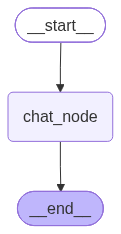

In [22]:
chatbot

In [ ]:
thread_id = "1"
intial_state = {"messages":[HumanMessage(content="What is the capital of India?")]}
config = {"configurable":{"thread_id":thread_id}}
output = chatbot.invoke(intial_state,config=config)

In [28]:
output["messages"][-1].content

'The capital of India is New Delhi.'

In [29]:
import ipywidgets as widgets
from IPython.display import display
from langchain_core.messages import HumanMessage

# Chat history
messages = []

# Widgets
text = widgets.Text(
    placeholder="Type your message...",
    description="You:",
    layout=widgets.Layout(width="80%")
)

send_btn = widgets.Button(
    description="Send",
    button_style="primary"
)

output_box = widgets.Output()

# Flag to stop the chat
chat_active = True
thread_id = "1"
config = {"configurable":{"thread_id":thread_id}}
def chat(_):
    global chat_active

    if not chat_active:
        return

    user_input = text.value.strip()

    if not user_input:
        return

    text.value = ""

    with output_box:
        print(f"You: {user_input}")

        if user_input.lower() in ["exit", "quit"]:
            print("\n👋 Chat ended.")
            text.disabled = True
            send_btn.disabled = True
            chat_active = False
            return

        messages.append(HumanMessage(content=user_input))

        state = {"messages": messages}

        response = chatbot.invoke(state, config=config)

        ai_message = response["messages"][-1]

        print(f"Bot: {ai_message.content}\n")

        messages.append(ai_message)


send_btn.on_click(chat)

# Press Enter to send
text.on_submit(chat)

display(text, send_btn, output_box)

C:\Users\admin\AppData\Local\Temp\ipykernel_15740\1441147446.py:65: DeprecationWarning: on_submit is deprecated. Instead, set the .continuous_update attribute to False and observe the value changing with: mywidget.observe(callback, 'value').
  text.on_submit(chat)


Text(value='', description='You:', layout=Layout(width='80%'), placeholder='Type your message...')

Button(button_style='primary', description='Send', style=ButtonStyle())

Output()

In [ ]:
chatbot.get_state(config=config)## her you can see the state of the graph and the messages exchanged in the chat session.

StateSnapshot(values={'messages': [HumanMessage(content='What is the capital of India?', additional_kwargs={}, response_metadata={}, id='c9453ed8-144d-4330-91d1-ace7347066cd'), AIMessage(content='The capital of India is New Delhi.', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 9, 'prompt_tokens': 42, 'total_tokens': 51, 'completion_time': 0.009603355, 'completion_tokens_details': None, 'prompt_time': 0.003923988, 'prompt_tokens_details': None, 'queue_time': 0.052205011, 'total_time': 0.013527343}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019fbb94-7aad-7912-9c69-9584d3516fb3-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 42, 'output_tokens': 9, 'total_tokens': 51}), HumanMessage(content='What is the capital of India?', additional_kwargs={}, response_metadata={}, id='d4e7975c-6129-

In [12]:
# while True:
#     user_input = input("You: ")
#     if user_input.strip().lower() in ["exit", "quit"]:
#         break
#     intial_state = {"messages":[HumanMessage(content=user_input)]}
#     output = chatbot.invoke(intial_state)
#     print("Bot:", output["messages"][-1].content)